## Setup and Run Experiments

In [ ]:
%load_ext autoreload
%autoreload 2

import itertools
from src.graph import *
from src.instance import *
from src.experiments.experiments import *
from src.experiments.objectives import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
N_PATHS = 5
GRAPH = BASIC_CITY

demand_low_var = lambda: np.random.normal(4.0, 0.1)
demand_high_var = lambda: np.random.normal(4.0, 1.0)


adj = get_graph(GRAPH)

base_vars = {
    "alpha_car": 1.0,
    "beta_car": 1.0,
    "zeta_car": (1.0, 0.5),
    "alpha_bus": 1.0,
    "beta_bus": 1.0,
    "zeta_bus": (1.0, 0.5),
    "zeta_none": (-2, 1.0),
}
variant_names = [
    "NoPref", "PrefCar", "StrongPrefCar", "PrefBus", "StrongPrefBus"
]
variants = [
    { },
    {
        "alpha_car": 1.1,
        "beta_car": 0.9,
    },
    {
        "alpha_car": 1.25,
        "beta_car": 0.75,
    },
    {
        "alpha_bus": 1.1,
        "beta_bus": 0.9,
    },
    {
        "alpha_bus": 1.25,
        "beta_bus": 0.75,
    },
]

variables = generate_var_combinations(base_vars, variants)

# params = get_varied_params([adj], [demand_low_var, demand_high_var], variables, N_PATHS)
params = get_varied_path_params([adj], [demand_low_var, demand_high_var], variables, 100, 10)

names = list(itertools.product([GRAPH], ["low_var", "high_var"], variant_names))

In [28]:
RESULTS_FOLDER = "results/path_test"

In [29]:
from src.pathinstance import new_path_instance
from src.colgensolver import ColgenSolver

ITERS = 3
results = []
for ps, ns in zip(params, names):
    name = f"EXP-{ns[0]}-{ns[1]}-{ns[2]}"
    experiment = EdgeRemovalBF(
        ps, name, Verbosity.LOW, False, True, RESULTS_FOLDER,
        meta_vars={"graph": ns[0], "demand": ns[1], "variant": ns[2]},
        new_inst=new_path_instance, new_solver=ColgenSolver
    )
    results.append(experiment.run(ITERS))


Running 'EXP-basic_city-low_var-NoPref' (1 / 3)...
REMOVING: None (Control)
REMOVING: ('L1', 'L2')
REMOVING: ('L1', 'M1')
REMOVING: ('L1', 'R1')
REMOVING: ('L2', 'M2')
REMOVING: ('L2', 'R2')
REMOVING: ('M1', 'M2')
REMOVING: ('M1', 'R1')
REMOVING: ('M2', 'R2')
REMOVING: ('R1', 'R2')

Running 'EXP-basic_city-low_var-NoPref' (2 / 3)...
REMOVING: None (Control)
REMOVING: ('L1', 'L2')
REMOVING: ('L1', 'M1')
REMOVING: ('L1', 'R1')
REMOVING: ('L2', 'M2')
REMOVING: ('L2', 'R2')
REMOVING: ('M1', 'M2')
REMOVING: ('M1', 'R1')
REMOVING: ('M2', 'R2')
REMOVING: ('R1', 'R2')

Running 'EXP-basic_city-low_var-NoPref' (3 / 3)...
REMOVING: None (Control)
REMOVING: ('L1', 'L2')
REMOVING: ('L1', 'M1')
REMOVING: ('L1', 'R1')
REMOVING: ('L2', 'M2')
REMOVING: ('L2', 'R2')
REMOVING: ('M1', 'M2')
REMOVING: ('M1', 'R1')
REMOVING: ('M2', 'R2')
REMOVING: ('R1', 'R2')

Experiment 'EXP-basic_city-low_var-NoPref' complete.

Running 'EXP-basic_city-low_var-PrefCar' (1 / 3)...
REMOVING: None (Control)
REMOVING: ('L1',

## Load and process results

In [30]:
from src.experiments.result import load_experiment_folder

experiments: List[Tuple[dict, List[ExperimentResult]]] = []
for subfolder in os.listdir(RESULTS_FOLDER):
    path = os.path.join(RESULTS_FOLDER, subfolder)
    experiments.append(load_experiment_folder(path))

In [ ]:
from src.experiments.objectives import *

objectives: Sequence[Objective] = [MeanTravelTime(), BusRidership(), JourniesMade()]
objective_names = list(map(lambda m: m.name, objectives))

_formal_names_map = {
    "Congestion": "$\\Omega_{congest}^{-}$",
    "Bus Usage": "$\\Omega_{bus}$",
    "Travellers": "$\\Omega_{travel}$",
}
formal_metric_names = [_formal_names_map[name] for name in objective_names]

In [ ]:
INCLUDE_NAME = False

col_names = ["name"] if INCLUDE_NAME else []
meta = experiments[0][0]
meta_vars = list(meta["other"].keys())
col_names += [
    *meta_vars,
    *meta["var_names"],
    "iter",
    *objective_names,
]
col_names

['graph',
 'demand',
 'variant',
 'EDGE_REMOVED',
 'iter',
 'Congestion',
 'Bus Usage',
 'Travellers']

In [ ]:
from pandas import DataFrame

USE_NEGATIVE_CONGESTION = True

data = []
for meta, results in experiments:
    var_vals = list(meta["other"].values())
    for result in results:
        row: list = [result.experiment_name] if INCLUDE_NAME else []
        row += [
            *var_vals,
            *result.experiment_vars,
            result.iteration
        ]
        for metric in objectives:
            v = metric.collect(result.solver)
            row.append(v)
        data.append(row)
df = DataFrame(data, columns=col_names)
if USE_NEGATIVE_CONGESTION:
    df["Congestion"] = -df["Congestion"]
df

,graph,demand,variant,EDGE_REMOVED,iter,Congestion,Bus Usage,Travellers
0,basic_city,high_var,NoPref,None,0,-0.1008,0.5013,0.5052
1,basic_city,high_var,NoPref,"(L1, L2)",0,-0.0786,0.5355,0.5294
2,basic_city,high_var,NoPref,"(L1, M1)",0,-0.0966,0.5309,0.5221
3,basic_city,high_var,NoPref,"(L1, R1)",0,-0.0976,0.5311,0.5105
4,basic_city,high_var,NoPref,"(L2, M2)",0,-0.0758,0.5731,0.5207
...,...,...,...,...,...,...,...,...
395,basic_city,low_var,StrongPrefCar,"(M2, R2)",1,-0.1192,0.4706,0.5395
396,basic_city,low_var,StrongPrefCar,"(M2, R2)",2,-0.1197,0.4680,0.5393
397,basic_city,low_var,StrongPrefCar,"(R1, R2)",0,-0.1168,0.4835,0.5439
398,basic_city,low_var,StrongPrefCar,"(R1, R2)",1,-0.1175,0.4846,0.5428


In [ ]:
group_cols = [col for col in df.columns if col not in objective_names + ['iter']]

df_avg = df.groupby(group_cols, as_index=False)[objective_names].mean()
df_avg

,graph,demand,variant,EDGE_REMOVED,Congestion,Bus Usage,Travellers
0,basic_city,high_var,NoPref,"(L1, L2)",-0.086100,0.536475,0.523425
1,basic_city,high_var,NoPref,"(L1, M1)",-0.092800,0.533600,0.513900
2,basic_city,high_var,NoPref,"(L1, R1)",-0.095550,0.530350,0.514050
3,basic_city,high_var,NoPref,"(L2, M2)",-0.079550,0.579100,0.515350
4,basic_city,high_var,NoPref,"(L2, R2)",-0.080675,0.590875,0.521075
...,...,...,...,...,...,...,...
95,basic_city,low_var,StrongPrefCar,"(M1, M2)",-0.117650,0.484650,0.542450
96,basic_city,low_var,StrongPrefCar,"(M1, R1)",-0.138250,0.398275,0.543250
97,basic_city,low_var,StrongPrefCar,"(M2, R2)",-0.119400,0.468575,0.539000
98,basic_city,low_var,StrongPrefCar,"(R1, R2)",-0.116950,0.483850,0.542750


In [ ]:
# df_avg['Congestion'] = 1 / df_avg['Congestion']
control_df = df_avg[df_avg["EDGE_REMOVED"] == "None"]
other_df = df_avg[df_avg["EDGE_REMOVED"] != "None"]

merged_df = other_df.merge(
    control_df[[*meta_vars, *objective_names]],
    on=meta_vars,
    suffixes=("", " Control")
)

def ratio(df, metric):
    cur = df[metric]
    control = df[f"{metric} Control"]
    df[f"{metric} rat"] = abs(np.log(cur / control))

for name in objective_names:
    ratio(merged_df, name)


merged_df

,graph,demand,variant,EDGE_REMOVED,Congestion,Bus Usage,Travellers,Congestion Control,Bus Usage Control,Travellers Control,Congestion rat,Bus Usage rat,Travellers rat
0,basic_city,high_var,NoPref,"(L1, L2)",-0.086100,0.536475,0.523425,-0.094125,0.500600,0.513375,0.089114,0.069213,0.019387
1,basic_city,high_var,NoPref,"(L1, M1)",-0.092800,0.533600,0.513900,-0.094125,0.500600,0.513375,0.014177,0.063839,0.001022
2,basic_city,high_var,NoPref,"(L1, R1)",-0.095550,0.530350,0.514050,-0.094125,0.500600,0.513375,0.015026,0.057730,0.001314
3,basic_city,high_var,NoPref,"(L2, M2)",-0.079550,0.579100,0.515350,-0.094125,0.500600,0.513375,0.168238,0.145668,0.003840
4,basic_city,high_var,NoPref,"(L2, R2)",-0.080675,0.590875,0.521075,-0.094125,0.500600,0.513375,0.154195,0.165797,0.014887
...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,basic_city,low_var,StrongPrefCar,"(L2, R2)",-0.125600,0.442950,0.543525,-0.142875,0.359425,0.545325,0.128868,0.208951,0.003306
86,basic_city,low_var,StrongPrefCar,"(M1, M2)",-0.117650,0.484650,0.542450,-0.142875,0.359425,0.545325,0.194256,0.298921,0.005286
87,basic_city,low_var,StrongPrefCar,"(M1, R1)",-0.138250,0.398275,0.543250,-0.142875,0.359425,0.545325,0.032906,0.102637,0.003812
88,basic_city,low_var,StrongPrefCar,"(M2, R2)",-0.119400,0.468575,0.539000,-0.142875,0.359425,0.545325,0.179491,0.265191,0.011666


## Graph Generation

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Sans Serif"

DPI = 300
FORMATS = ["png", "pdf"]


# Sum the target columns into a new column
if USE_NEGATIVE_CONGESTION:
    merged_df['mixed_opt'] = (merged_df['Congestion rat']) + merged_df['Bus Usage rat'] + merged_df['Travellers rat']
else:
    merged_df['mixed_opt'] = (-merged_df['Congestion rat']) + merged_df['Bus Usage rat'] + merged_df['Travellers rat']

# For each (graph, demand, variant), find the row with the max total
idx = merged_df.groupby(['graph', 'demand', 'variant'])['mixed_opt'].idxmax()

# Select those rows
max_rows = merged_df.loc[idx].reset_index(drop=True)
# max_rows = max_rows[max_rows['demand'] == 'low_var']

ordering = ['StrongPrefCar', 'PrefCar', 'NoPref', 'PrefBus', 'StrongPrefBus']
max_rows['variant'] = pd.Categorical(max_rows['variant'], categories=ordering, ordered=True)
max_rows.sort_values(['demand', 'variant'], inplace=True)
max_rows

,graph,demand,variant,EDGE_REMOVED,Congestion,Bus Usage,Travellers,Congestion Control,Bus Usage Control,Travellers Control,Congestion rat,Bus Usage rat,Travellers rat,mixed_opt
4,basic_city,high_var,StrongPrefCar,"(R1, R2)",-0.110575,0.475725,0.541250,-0.135300,0.361175,0.547825,0.201801,0.275477,0.012075,0.489352
2,basic_city,high_var,PrefCar,"(M1, M2)",-0.091500,0.567275,0.523225,-0.104125,0.448500,0.530400,0.129253,0.234936,0.013620,0.377808
0,basic_city,high_var,NoPref,"(M1, M2)",-0.072525,0.606075,0.526125,-0.094125,0.500600,0.513375,0.260692,0.191196,0.024532,0.476421
1,basic_city,high_var,PrefBus,"(R1, R2)",-0.065925,0.647050,0.545250,-0.081375,0.551875,0.536750,0.210550,0.159102,0.015712,0.385364
3,basic_city,high_var,StrongPrefBus,"(R1, R2)",-0.056075,0.703750,0.590700,-0.073875,0.627100,0.576125,0.275684,0.115317,0.024984,0.415985
9,basic_city,low_var,StrongPrefCar,"(R1, R2)",-0.116950,0.483850,0.542750,-0.142875,0.359425,0.545325,0.200224,0.297269,0.004733,0.502226
7,basic_city,low_var,PrefCar,"(M1, M2)",-0.090075,0.562050,0.527600,-0.110825,0.445975,0.524800,0.207310,0.231328,0.005321,0.443959
5,basic_city,low_var,NoPref,"(R1, R2)",-0.075600,0.609950,0.523250,-0.093900,0.500000,0.515200,0.216774,0.198769,0.015504,0.431047
6,basic_city,low_var,PrefBus,"(R1, R2)",-0.068475,0.651650,0.545650,-0.085800,0.551975,0.536250,0.225550,0.166005,0.017377,0.408932
8,basic_city,low_var,StrongPrefBus,"(M1, M2)",-0.057075,0.707325,0.587750,-0.072275,0.624850,0.576625,0.236112,0.123979,0.019110,0.379200


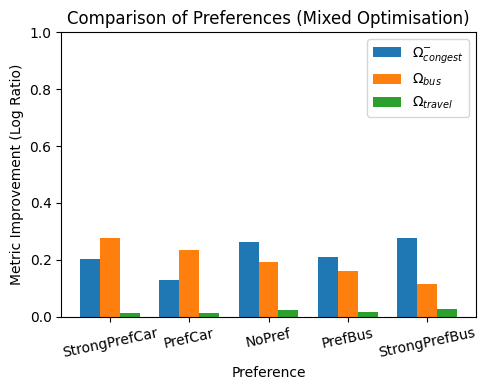

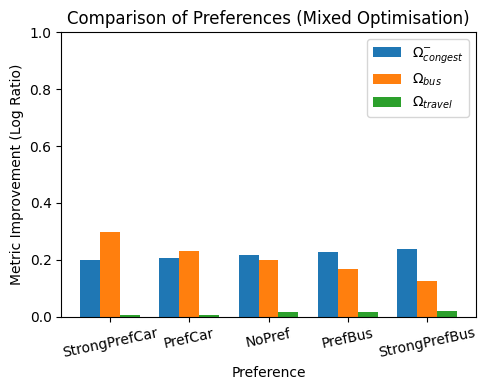

In [ ]:
def plot_variants(df, graph, demand):
    # Filter for graph and demand
    filtered = df[(df['graph'] == graph) & (df['demand'] == demand)].copy()
    # for col in metric_names:
    #     max_val = filtered[col].max()
    #     if max_val != 0:
    #         filtered[col] = filtered[col] / max_val
    #         print(filtered[col])

    # Set up plot
    x = np.arange(len(filtered))  # one bar group per variant
    bar_width = 0.25

    fig, ax = plt.subplots(figsize=(5, 4))

    for i, metric in enumerate(objective_names):
        name = f'{metric} rat'
        ax.bar(x + i * bar_width, filtered[name], width=bar_width, label=formal_metric_names[i])

    ax.set_xticks(x + bar_width)
    ax.set_xticklabels(filtered['variant'], rotation=12)
    ax.set_xlabel('Preference')
    ax.set_ylabel('Metric Improvement (Log Ratio)')
    ax.set_ylim(0.0, 1.0)
    ax.set_title(f'Comparison of Preferences (Mixed Optimisation)')
    ax.legend(loc='upper right')
    plt.tight_layout()

for (g, d) in itertools.product(max_rows['graph'].unique(), max_rows['demand'].unique()):
    plot_variants(max_rows, g, d)
    for fmt in FORMATS:
        plt.savefig(f'./results/figs/pref_rat-{g}-{d}.{fmt}', format=fmt, dpi=DPI)

('basic_city', 'high_var', 'NoPref')
('basic_city', 'high_var', 'PrefBus')
('basic_city', 'high_var', 'PrefCar')
('basic_city', 'high_var', 'StrongPrefBus')
('basic_city', 'high_var', 'StrongPrefCar')
('basic_city', 'low_var', 'NoPref')
('basic_city', 'low_var', 'PrefBus')
('basic_city', 'low_var', 'PrefCar')
('basic_city', 'low_var', 'StrongPrefBus')
('basic_city', 'low_var', 'StrongPrefCar')


,graph,demand,variant,EDGE_REMOVED,Congestion,Bus Usage,Travellers,Congestion Control,Bus Usage Control,Travellers Control,Congestion rat,Bus Usage rat,Travellers rat,mixed_opt
89,basic_city,low_var,StrongPrefCar,"(R1, R2)",-0.11695,0.48385,0.54275,-0.142875,0.359425,0.545325,0.200224,0.297269,0.004733,0.502226
89,basic_city,low_var,StrongPrefCar,"(R1, R2)",-0.11695,0.48385,0.54275,-0.142875,0.359425,0.545325,0.200224,0.297269,0.004733,0.502226
86,basic_city,low_var,StrongPrefCar,"(M1, M2)",-0.11765,0.48465,0.54245,-0.142875,0.359425,0.545325,0.194256,0.298921,0.005286,0.498463
82,basic_city,low_var,StrongPrefCar,"(L1, M1)",-0.13685,0.40330,0.54435,-0.142875,0.359425,0.545325,0.043085,0.115175,0.001790,0.160049


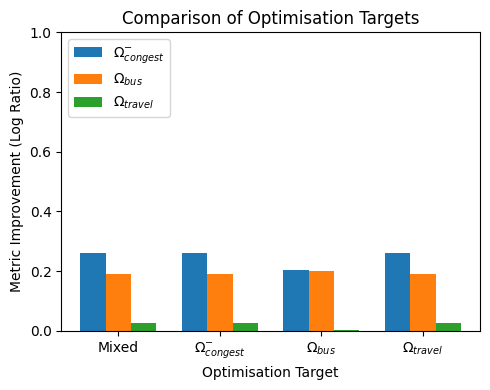

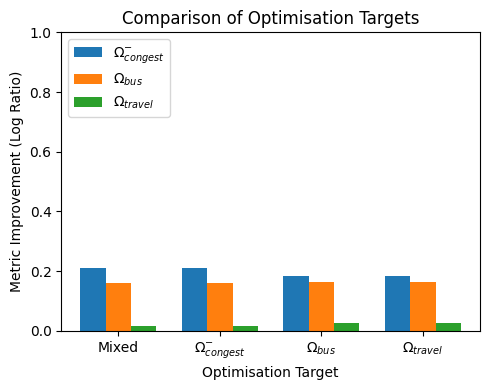

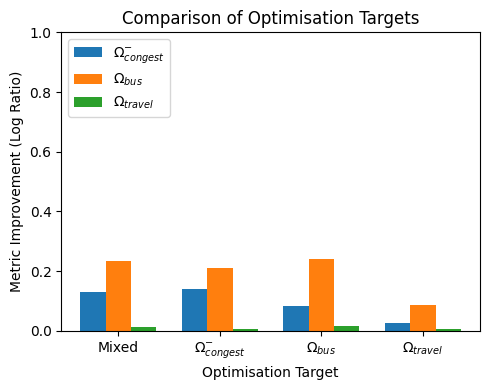

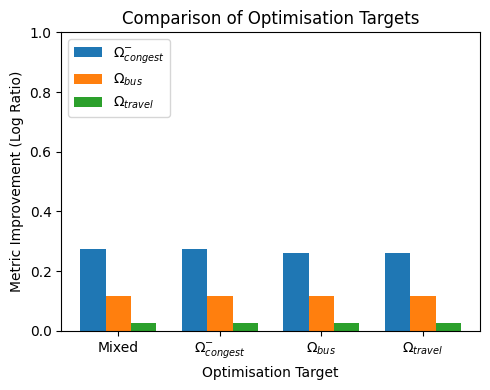

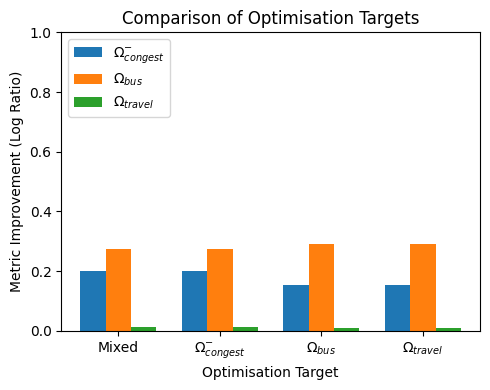

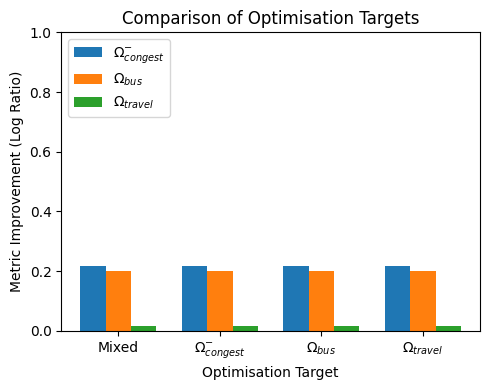

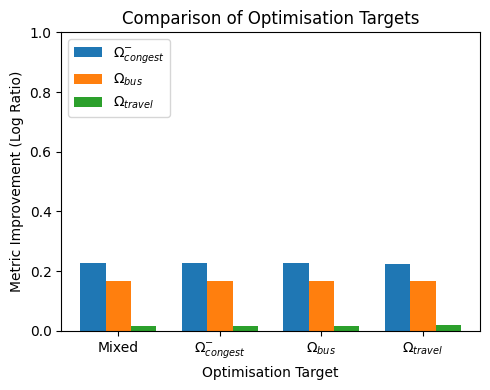

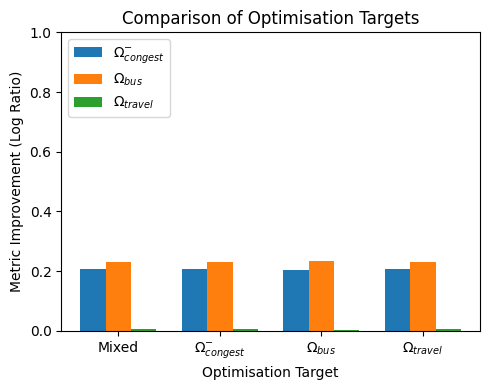

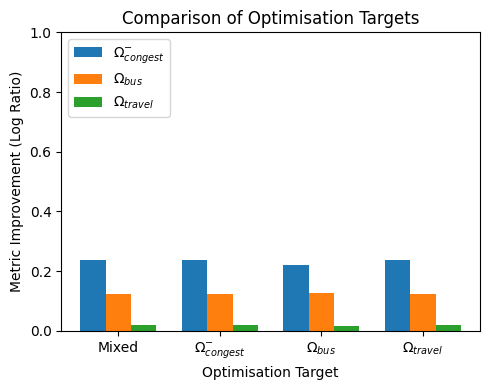

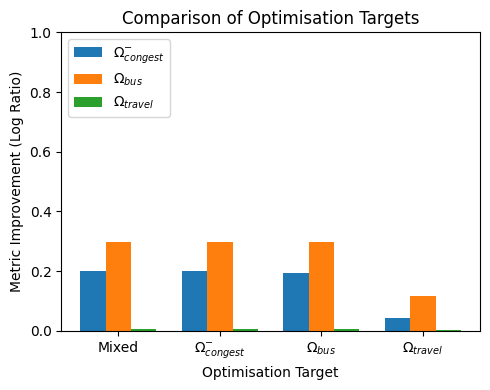

In [ ]:
def get_max_row(grouped_df, index, col):
    group = grouped_df.get_group(index)
    return group.loc[group[col].idxmax()]

grouped_df = merged_df.groupby(['graph', 'demand', 'variant'])
# control_grouped = control_df.set_index(['graph', 'demand', 'variant'])
for index, vals in grouped_df:
    rows = []
    # rows.append(control_grouped.loc[index])
    rows.append(get_max_row(grouped_df, index, 'mixed_opt'))
    for metric in objective_names:
        # print(vals[metric])
        rows.append(get_max_row(grouped_df, index, metric))
        
    df_opts = pd.DataFrame(rows)
        
    x = np.arange(len(rows))  # one bar group per variant
    bar_width = 0.25

    fig, ax = plt.subplots(figsize=(5, 4))

    for i, metric in enumerate(objective_names):
        name = f'{metric} rat'
        ax.bar(x + i * bar_width, df_opts[name], width=bar_width, label=formal_metric_names[i])

    ax.set_xticks(x + bar_width)
    labels = ['Mixed'] + [name for name in formal_metric_names]
    ax.set_xticklabels(labels, rotation=0)
    ax.set_xlabel('Optimisation Target')
    ax.set_ylabel('Metric Improvement (Log Ratio)')
    ax.set_ylim(0.0, 1.0)
    ax.set_title(f'Comparison of Optimisation Targets')
    ax.legend(loc='upper left')
    plt.tight_layout()
    g, d, v = index
    print(index)
    for fmt in FORMATS:
        plt.savefig(f'./results/figs/opt_targets-{g}-{d}-{v}.{fmt}', format=fmt, dpi=DPI)
df_opts